# German credit risk prediciton with Scikit-learn for model monitoring

This notebook should be run in a Watson Studio project, using **Default Python 3.12** runtime environment. It requires service credentials for the following Cloud services:
  * watsonx.ai Runtime

The notebook will train, create and deploy a German Credit Risk model.

### Learning goals

In this notebook, you will learn how to:

-  Explore data
-  Prepare data for training and evaluation
-  Create a scikit-learn pipeline
-  Train and evaluate a model
-  Store a model in the watsonx.ai Runtime repository
-  Deploy and score the model

### Contents

1. [Set up the environment](#Set-up-the-environment)
2. [Load the training data from GitHub](#Load-the-training-data-from-GitHub)
3. [Explore data](#Explore-data)
4. [Save training data to Cloud Object Storage](#Save-training-data-to-Cloud-Object-Storage)
5. [Create a model](#Create-a-model)
6. [Publish the model](#Publish-the-model)
7. [Deploy and score](#Deploy-and-score)
8. [Cleanup](#Cleanup)
9. [Summary and next steps](#Summary-and-next-steps)

<a id="Set-up-the-environment"></a>
## Set up the environment

Before you use the sample code in this notebook, you must perform the following setup tasks:

-  Create a <a href="https://cloud.ibm.com/catalog/services/watsonxai-runtime" target="_blank" rel="noopener no referrer">watsonx.ai Runtime Service</a> instance (a free plan is offered and information about how to create the instance can be found <a href="https://dataplatform.cloud.ibm.com/docs/content/wsj/getting-started/wml-plans.html?context=wx&audience=wdp" target="_blank" rel="noopener no referrer">here</a>).

### Install and import the `ibm-watsonx-ai` and dependecies
**Note:** `ibm-watsonx-ai` documentation can be found <a href="https://ibm.github.io/watsonx-ai-python-sdk/index.html" target="_blank" rel="noopener no referrer">here</a>.

In [1]:
%pip install wget | tail -n 1
%pip install matplotlib | tail -n 1
%pip install -U ibm-watsonx-ai | tail -n 1
%pip install "scikit-learn==1.6.1" | tail -n 1

### Connection to watsonx.ai Runtime

Authenticate the watsonx.ai Runtime service on IBM Cloud. You need to provide platform `api_key` and instance `location`.

You can use [IBM Cloud CLI](https://cloud.ibm.com/docs/cli/index.html) to retrieve platform API Key and instance location.

API Key can be generated in the following way:
```
ibmcloud login
ibmcloud iam api-key-create API_KEY_NAME
```

In result, get the value of `api_key` from the output.


Location of your watsonx.ai Runtime instance can be retrieved in the following way:
```
ibmcloud login --apikey API_KEY -a https://cloud.ibm.com
ibmcloud resource service-instance INSTANCE_NAME
```

In result, get the value of `location` from the output.

**Tip**: Your `Cloud API key` can be generated by going to the [**Users** section of the Cloud console](https://cloud.ibm.com/iam#/users). From that page, click your name, scroll down to the **API Keys** section, and click **Create an IBM Cloud API key**. Give your key a name and click **Create**, then copy the created key and paste it below. You can also get a service specific url by going to the [**Endpoint URLs** section of the watsonx.ai Runtime docs](https://cloud.ibm.com/apidocs/machine-learning).  You can check your instance location in your  <a href="https://cloud.ibm.com/catalog/services/watsonxai-runtime" target="_blank" rel="noopener no referrer">watsonx.ai Runtime Service</a> instance details.

You can also get service specific apikey by going to the [**Service IDs** section of the Cloud Console](https://cloud.ibm.com/iam/serviceids).  From that page, click **Create**, then copy the created key and paste it below.

**Action**: Enter your `url` and `api_key` in the following cell.

In [2]:
import getpass

from ibm_watsonx_ai import Credentials

credentials = Credentials(
    url="https://us-south.ml.cloud.ibm.com",
    api_key=getpass.getpass("Please enter your watsonx.ai api key (hit enter): "),
)

In [3]:
from ibm_watsonx_ai import APIClient

client = APIClient(credentials)

### Working with spaces

First of all, you need to create a space that will be used for your work. If you do not have space already created, you can use [Deployment Spaces Dashboard](https://dataplatform.cloud.ibm.com/ml-runtime/spaces?context=wx) to create one.

- Click New Deployment Space
- Create an empty space
- Select Cloud Object Storage
- Select watsonx.ai Runtime instance and press Create
- Copy `space_id` and paste it below

**Tip**: You can also use SDK to prepare the space for your work. More information can be found [here](https://github.com/IBM/watson-machine-learning-samples/blob/master/cloud/notebooks/python_sdk/instance-management/Space%20management.ipynb).

**Action**: Assign space ID below

In [4]:
space_id = "PASTE YOUR SPACE ID HERE"

You can use `list` method to print all existing spaces.

In [ ]:
client.spaces.list(limit=10)

To be able to interact with all resources available in watsonx.ai Runtime, you need to set **space** which you will be using.

In [5]:
client.set.default_space(space_id)

'SUCCESS'

### Connections to COS

In next cell we read the COS credentials from the space.

In [6]:
cos_credentials = client.spaces.get_details(space_id=space_id)["entity"]["storage"][
    "properties"
]

At this point, the notebook is ready to run. You can either run the cells one at a time, or click the **Kernel** option above and select **Restart and Run All** to run all the cells.

<a id="Load-the-training-data-from-GitHub"></a>
## Load the training data from GitHub

In [7]:
import os

import wget

training_data_file_name = "german_credit_data_biased_training.csv"
if not os.path.isfile(training_data_file_name):
    wget.download(
        "https://raw.githubusercontent.com/pmservice/ai-openscale-tutorials/master/assets/historical_data/german_credit_risk/wml/german_credit_data_biased_training.csv",
    )

In [8]:
import numpy as np
import pandas as pd

data_df = pd.read_csv(training_data_file_name)

<a id="Explore-data"></a>
## Explore data

In [9]:
data_df.head()

,CheckingStatus,LoanDuration,CreditHistory,LoanPurpose,LoanAmount,ExistingSavings,EmploymentDuration,InstallmentPercent,Sex,OthersOnLoan,...,OwnsProperty,Age,InstallmentPlans,Housing,ExistingCreditsCount,Job,Dependents,Telephone,ForeignWorker,Risk
0,0_to_200,31,credits_paid_to_date,other,1889,100_to_500,less_1,3,female,none,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
1,less_0,18,credits_paid_to_date,car_new,462,less_100,1_to_4,2,female,none,...,savings_insurance,37,stores,own,2,skilled,1,none,yes,No Risk
2,less_0,15,prior_payments_delayed,furniture,250,less_100,1_to_4,2,male,none,...,real_estate,28,none,own,2,skilled,1,yes,no,No Risk
3,0_to_200,28,credits_paid_to_date,retraining,3693,less_100,greater_7,3,male,none,...,savings_insurance,32,none,own,1,skilled,1,none,yes,No Risk
4,no_checking,28,prior_payments_delayed,education,6235,500_to_1000,greater_7,3,male,none,...,unknown,57,none,own,2,skilled,1,none,yes,Risk


In [10]:
print("Columns: ", list(data_df.columns))
print("Number of columns: ", len(data_df.columns))

Columns:  ['CheckingStatus', 'LoanDuration', 'CreditHistory', 'LoanPurpose', 'LoanAmount', 'ExistingSavings', 'EmploymentDuration', 'InstallmentPercent', 'Sex', 'OthersOnLoan', 'CurrentResidenceDuration', 'OwnsProperty', 'Age', 'InstallmentPlans', 'Housing', 'ExistingCreditsCount', 'Job', 'Dependents', 'Telephone', 'ForeignWorker', 'Risk']
Number of columns:  21


As you can see, the data contains twenty one fields. `Risk` field is the one you would like to predict using feedback data.

In [11]:
print("Number of records: ", data_df.Risk.count())

Number of records:  5000


In [12]:
target_count = data_df.groupby("Risk")["Risk"].count()
target_count

Risk
No Risk    3330
Risk       1670
Name: Risk, dtype: int64

### Visualize data

<Axes: ylabel='Risk'>

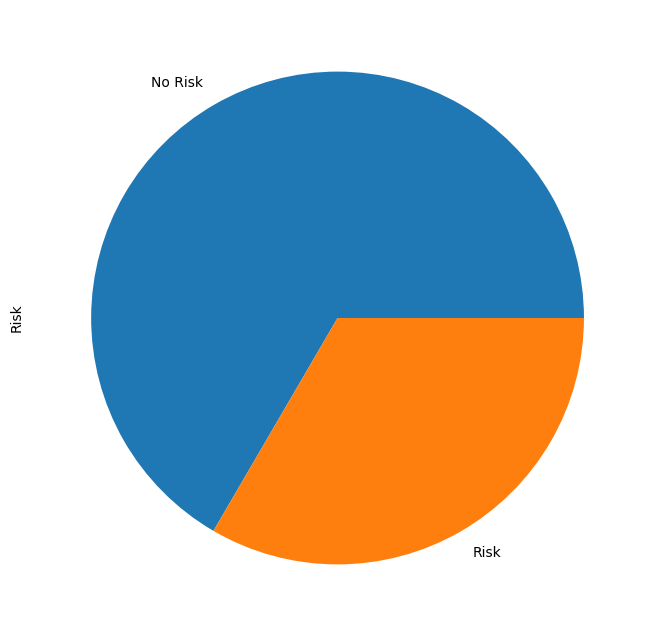

In [13]:
target_count.plot.pie(figsize=(8, 8))

<a id="Save-training-data-to-Cloud-Object-Storage"></a>
## Save training data to Cloud Object Storage

In [14]:
import ibm_boto3
from ibm_botocore.client import Config

cos_client = ibm_boto3.resource(
    "s3",
    ibm_api_key_id=cos_credentials["credentials"]["editor"]["api_key"],
    ibm_service_instance_id=cos_credentials["resource_crn"],
    ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
    config=Config(signature_version="oauth"),
    endpoint_url=cos_credentials["endpoint_url"],
)

In [15]:
with open(training_data_file_name, "rb") as file_data:
    cos_client.Object(
        cos_credentials["bucket_name"], training_data_file_name
    ).upload_fileobj(Fileobj=file_data)

<a id="Create-a-model"></a>

## Create a model
In this section you will learn how to:

- Prepare data for training a model
- Create machine learning pipeline
- Train a model

In [16]:
MODEL_NAME = "Scikit German Risk Model WML V4"

DEPLOYMENT_NAME = "Scikit German Risk Deployment WML V4"

### You will start with importing required libraries

In [17]:
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

### Splitting the data into train and test

In [18]:
train_data, test_data = train_test_split(data_df, test_size=0.2)

### Preparing the pipeline

In [19]:
features_idx = np.s_[0:-1]
all_records_idx = np.s_[:]
first_record_idx = np.s_[0]

In this step you will encode target column labels into numeric values. You can use `inverse_transform` to decode numeric predictions into labels.

In [20]:
string_fields = [
    type(fld) is str for fld in train_data.iloc[first_record_idx, features_idx]
]
ct = ColumnTransformer(
    [
        (
            "ohe",
            OneHotEncoder(),
            list(np.array(train_data.columns)[features_idx][string_fields]),
        )
    ]
)
clf_linear = SGDClassifier(loss="log_loss", penalty="l2", max_iter=1000, tol=1e-5)

pipeline_linear = Pipeline([("ct", ct), ("clf_linear", clf_linear)])

### Train a model

In [21]:
risk_model = pipeline_linear.fit(train_data.drop("Risk", axis=1), train_data.Risk)

### Evaluate the model

In [22]:
from sklearn.metrics import roc_auc_score

predictions = risk_model.predict(test_data.drop("Risk", axis=1))
indexed_preds = [0 if prediction == "No Risk" else 1 for prediction in predictions]

real_observations = test_data.Risk.replace("Risk", 1)
real_observations = real_observations.replace("No Risk", 0).values

auc = roc_auc_score(real_observations, indexed_preds)
print(auc)

0.7240044573494173


<a id="Publish-the-model"></a>
## Publish the model

In this section, the notebook uses the supplied watsonx.ai Runtime credentials to save the model (including the pipeline) to the watsonx.ai Runtime instance. Previous versions of the model are removed so that the notebook can be run again, resetting all data for another demo.

In [23]:
software_spec_id = client.software_specifications.get_id_by_name("runtime-25.1-py3.12")
print("Software Specification ID: {}".format(software_spec_id))
model_props = {
    client.repository.ModelMetaNames.NAME: "{}".format(MODEL_NAME),
    client.repository.ModelMetaNames.TYPE: "scikit-learn_1.6",
    client.repository.ModelMetaNames.SOFTWARE_SPEC_ID: software_spec_id,
}

Software Specification ID: f47ae1c3-198e-5718-b59d-2ea471561e9e


In [24]:
print("Storing model ...")

published_model_details = client.repository.store_model(
    model=risk_model,
    meta_props=model_props,
    training_data=data_df.drop(["Risk"], axis=1),
    training_target=data_df.Risk,
)
model_id = client.repository.get_model_id(published_model_details)
print("Done")
print("Model ID: {}".format(model_id))

Storing model ...
Done
Model ID: 31524176-f59b-40b1-8cf0-c8e9a9624064


<a id="Deploy-and-score"></a>
## Deploy and score

The next section of the notebook deploys the model as a RESTful web service in watsonx.ai Runtime. The deployed model will have a scoring URL you can use to send data to the model for predictions.

In [25]:
print("Deploying model...")
metadata = {
    client.deployments.ConfigurationMetaNames.NAME: DEPLOYMENT_NAME,
    client.deployments.ConfigurationMetaNames.ONLINE: {},
}
deployment = client.deployments.create(model_id, meta_props=metadata)
deployment_id = client.deployments.get_id(deployment)

print("Model id: {}".format(model_id))
print("Deployment id: {}".format(deployment_id))

Deploying model...


######################################################################################

Synchronous deployment creation for id: '31524176-f59b-40b1-8cf0-c8e9a9624064' started

######################################################################################


initializing
Note: online_url and serving_urls are deprecated and will be removed in a future release. Use inference instead.
.........
ready


-----------------------------------------------------------------------------------------------
Successfully finished deployment creation, deployment_id='b7040aaa-a80a-4803-925d-04a1db9b0788'
-----------------------------------------------------------------------------------------------


Model id: 31524176-f59b-40b1-8cf0-c8e9a9624064
Deployment id: b7040aaa-a80a-4803-925d-04a1db9b0788


### Score the model

In [26]:
fields = [
    "CheckingStatus",
    "LoanDuration",
    "CreditHistory",
    "LoanPurpose",
    "LoanAmount",
    "ExistingSavings",
    "EmploymentDuration",
    "InstallmentPercent",
    "Sex",
    "OthersOnLoan",
    "CurrentResidenceDuration",
    "OwnsProperty",
    "Age",
    "InstallmentPlans",
    "Housing",
    "ExistingCreditsCount",
    "Job",
    "Dependents",
    "Telephone",
    "ForeignWorker",
]

values = [
    [
        "no_checking",
        13,
        "credits_paid_to_date",
        "car_new",
        1343,
        "100_to_500",
        "1_to_4",
        2,
        "female",
        "none",
        3,
        "savings_insurance",
        46,
        "none",
        "own",
        2,
        "skilled",
        1,
        "none",
        "yes",
    ],
    [
        "no_checking",
        24,
        "prior_payments_delayed",
        "furniture",
        4567,
        "500_to_1000",
        "1_to_4",
        4,
        "male",
        "none",
        4,
        "savings_insurance",
        36,
        "none",
        "free",
        2,
        "management_self-employed",
        1,
        "none",
        "yes",
    ],
]

scoring_payload = {"input_data": [{"fields": fields, "values": values}]}

In [27]:
predictions = client.deployments.score(deployment_id, scoring_payload)
predictions

{'predictions': [{'fields': ['prediction', 'probability'],
   'values': [['Risk', [0.39406169087462684, 0.6059383091253732]],
    ['No Risk', [0.6383700211404585, 0.3616299788595415]]]}]}

<a id="Cleanup"></a>
## Cleanup

If you want to clean up all created assets:
- experiments
- trainings
- pipelines
- model definitions
- models
- functions
- deployments

please follow up this sample [notebook](https://github.com/IBM/watson-machine-learning-samples/blob/master/cloud/notebooks/python_sdk/instance-management/Machine%20Learning%20artifacts%20management.ipynb).

<a id="Summary-and-next-steps"></a>
## Summary and next steps

You successfully completed this notebook! 
 
You have finished the hands-on lab for IBM watsonx.ai. You created, published and deployed Scikit-Learn german credit risk model. 

Check out our <a href="https://dataplatform.cloud.ibm.com/docs/content/wsj/getting-started/welcome-main.html?context=wx" target="_blank" rel="noopener noreferrer">Online Documentation</a> for more samples, tutorials, documentation, how-tos, and blog posts. 

You can now run the model monitoring [notebook](Monitor%20credit%20risk%20model%20with%20Watson%20Openscale.ipynb). You need to pass deployed model id in mentioned notebook

## Authors

**Lukasz Cmielowski**, PhD, is an Automation Architect and Data Scientist at IBM with a track record of developing enterprise-level applications that substantially increases clients' ability to turn data into actionable knowledge.

**Szymon Kucharczyk**, Software Engineer at IBM watsonx.ai.

**Mateusz Szewczyk**, Software Engineer at watsonx.ai.

Copyright © 2020-2026 IBM. This notebook and its source code are released under the terms of the MIT License.